# EDA

- [Introducción a la competición](#Titanic---Machine-Learning-from-Disaster)
- [Descripción del dataset](#Descripción-del-dataset)
- [Importar librerías](#Importar-librerías)
- [Lectura de datos](#Lectura-de-datos)
- [EDA](#Exploratory-Data-Analysis)
    - [Hipótesis previas](#Hipótesis-previas)
    - [Exploración](#Exporación-del-dataset)
    - [Análisis univariable](#Análisis-Univariable)
        - [Estadísticas descriptivas](#Estadísticas-descriptivas) 
        - [Visualizaciones](#Visualizaciones)
    - [Análisis multivariable](#Análisis-Multivariable)
    - [Testeo de hipótesis](#Testeo-Hipótesis)
- [Conclusiones](#Conclusiones)

## Titanic - Machine Learning from Disaster
El hundimiento del Titanic es uno de los naufragios más infames de la historia.

El 15 de abril de 1912, durante su viaje inaugural, el ampliamente considerado "insumergible" RMS Titanic se hundió tras chocar con un iceberg. Desafortunadamente, no había suficientes botes salvavidas para todos a bordo, lo que resultó en la muerte de 1502 de los 2224 pasajeros y tripulantes.

Si bien hubo un elemento de suerte en la supervivencia, parece que algunos grupos de personas tenían más probabilidades de sobrevivir que otros.

En este desafío, te pedimos que construyas un modelo predictivo que responda a la pregunta: "¿qué tipo de personas tenían más probabilidades de sobrevivir?" utilizando los datos de los pasajeros (es decir, nombre, edad, género, clase socioeconómica, etc.).

[Enlace a la competición en kaggle](https://www.kaggle.com/competitions/titanic)

## Descripción del dataset

Los datos se han dividido en dos grupos:

- Conjunto de entrenamiento (train.csv)
- Conjunto de prueba (test.csv)

El **conjunto de entrenamiento** debe utilizarse para construir tus modelos de machine learning. Para el conjunto de entrenamiento, proporcionamos el resultado (también conocido como "ground truth") para cada pasajero. Tu modelo se basará en "características" como el género y la clase de los pasajeros. También puedes usar ingeniería de características para crear nuevas variables.

El **conjunto de prueba** debe utilizarse para evaluar qué tan bien se desempeña tu modelo con datos no vistos. Para el conjunto de prueba, no proporcionamos la verdad real para cada pasajero. Es tu tarea predecir estos resultados. Para cada pasajero en el conjunto de prueba, utiliza el modelo que entrenaste para predecir si sobrevivió o no al hundimiento del Titanic.

### Diccionario de Datos

| **Variable** | **Definición**                                  | **Clave**                                      |
|:------------:|:-----------------------------------------------:|:----------------------------------------------:|
| survival     | Supervivencia                                   | `0 = No, 1 = Sí`                               |
| pclass       | Clase del boleto                                | `1 = 1ra, 2 = 2da, 3 = 3ra`                    |
| sex          | Sexo                                            |                                                |
| age          | Edad en años                                    |                                                |
| sibsp        | Número de hermanos/cónyuges a bordo del Titanic |                                                |
| parch        | Número de padres/hijos a bordo del Titanic      |                                                |
| ticket       | Número de boleto                                |                                                |
| fare         | Tarifa del pasajero                             |                                                |
| cabin        | Número de cabina                                |                                                |
| embarked     | Puerto de embarque                              | `C = Cherburgo, Q = Queenstown, S = Southampton` |


### Notas sobre las Variables

- **pclass**: Un indicador del estatus socioeconómico (SES)

    - 1ra = Upper

    - 2da = Middle

    - 3ra = Lower
      
- **age**: La edad es fraccionada si es menor a 1. Si la edad es estimada, aparece en la forma xx.5
  
- **sibsp**: El conjunto de datos define las relaciones familiares de esta manera...
  
    - Sibling = brother, sister, stepbrother, stepsister
  
    - Spouse = husband, wife (se ignoraron amantes y prometidos)
  
- **parch**: El conjunto de datos define las relaciones familiares de esta manera...
  
    - Parent = mother, father

    - Child = daughter, son, stepdaughter, stepson

Algunos niños viajaban solo con una niñera, por lo tanto, parch=0 para ellos.

## Importar librerías

In [ ]:
# Entorno de la asignatura: proyecto_ml (kernel "Python (proyecto_ml)").
# Ya incluye todas las librerías de este notebook: no hace falta instalar nada.

In [3]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

## Lectura de datos

In [4]:
INPUT_ZIP = "./00_Data/Raw/titanic.zip"  # Directorio del zip
OUTPUT_FOLDER = "./00_Data/Raw"  # Directorio de destino
TRAIN_FILENAME = "train.csv"  # Nombre del fichero de entrenamiento

def fetch_data(input_path=INPUT_ZIP, output_dir=OUTPUT_FOLDER):
    """
    Extrae el contenido de un archivo ZIP en un directorio de destino.

    Parámetros:
    -----------
    input_path : str, opcional
        Ruta al archivo ZIP que se desea descomprimir. El valor predeterminado es la variable 'INPUT_ZIP'.
        
    output_dir : str, opcional
        Directorio en el cual se extraerá el contenido del archivo ZIP. Si el directorio no existe,
        será creado automáticamente. El valor predeterminado es la variable 'OUTPUT_FOLDER'.

    Comportamiento:
    ---------------
    - Crea el directorio de destino si no existe.
    - Descomprime el archivo ZIP en el directorio de destino.

    Excepciones:
    ------------
    Puede lanzar una excepción si el archivo ZIP no existe o si hay problemas al descomprimirlo.

    Ejemplo de uso:
    ---------------
    fetch_data('data.zip', 'output/')
    """
    # Comprobación de que el directorio de destino existe
    os.makedirs(output_dir, exist_ok=True)

    # Descomprime el archivo ZIP en caso de que no haya ningún csv en la carpeta
    if(len([file for file in os.listdir(output_dir) if file.endswith('.csv')]) == 0):
        with zipfile.ZipFile(input_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)


def load_data(directory=OUTPUT_FOLDER, filename=TRAIN_FILENAME):
    """
    Lee un archivo CSV desde el directorio especificado.

    Parámetros:
    -----------
    directory : str
        El directorio donde se encuentra el archivo CSV.
        
    filename : str
        El nombre del archivo CSV a leer (incluyendo la extensión .csv).

    Retorna:
    --------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del archivo CSV.

    Excepciones:
    ------------
    FileNotFoundError:
        Se lanza si el archivo no existe en el directorio dado.
    
    Ejemplo de uso:
    ---------------
    df = read_csv_from_directory('data', 'file.csv')
    """
    # Construir la ruta completa al archivo CSV
    file_path = os.path.join(directory, filename)

    # Verificar si el archivo existe
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"El archivo {filename} no se encuentra en el directorio {directory}")

    # Leer el archivo CSV en un DataFrame
    return pd.read_csv(file_path)

fetch_data()
df = load_data()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Hipótesis previas

1. **Hipótesis de Género**: Las mujeres tuvieron una mayor probabilidad de sobrevivir que los hombres debido al protocolo de evacuación de "mujeres y niños primero".

2. **Hipótesis de Clase**: Los pasajeros de clases más altas (`Pclass = 1`) tuvieron una mayor probabilidad de sobrevivir en comparación con los pasajeros de clases más bajas, reflejando las desigualdades sociales de la época.

3. **Hipótesis de Edad**: Los pasajeros más jóvenes (niños) tuvieron una mayor probabilidad de sobrevivir debido a que se les dio prioridad en los esfuerzos de rescate.

4. **Hipótesis de Tamaño de la Familia**: Los pasajeros que viajaban con familia tuvieron mayores probabilidades de sobrevivir en comparación con aquellos que viajaban solos. Sin embargo, familias muy grandes pudieron tener dificultades para escapar juntas, reduciendo sus posibilidades de supervivencia.

5. **Hipótesis de la Tarifa**: Los pasajeros que pagaron tarifas más altas tuvieron una mayor probabilidad de sobrevivir, ya que es probable que estuvieran en camarotes de clases superiores y tuvieran mejor acceso a los botes salvavidas.

6. **Hipótesis del Punto de Embarque**: Los pasajeros que embarcaron en ciertos puntos, como Cherburgo (`Embarked = C`), tuvieron mayores probabilidades de sobrevivir debido a diferencias en riqueza o ubicación de los camarotes.

7. **Hipótesis de Disponibilidad de Cabina**: Los pasajeros con información de cabina disponible (`Cabin` no nulo) tuvieron una mayor probabilidad de sobrevivir, ya que probablemente estaban en las secciones de clase alta del barco.

8. **Hipótesis de Título**: Los pasajeros con ciertos títulos, como `Mrs`, `Miss` o `Master` (niños), tuvieron mejores probabilidades de sobrevivir que otros, reflejando su estatus social o edad.

9. **Hipótesis del Número de Ticket**: Los pasajeros con números de ticket similares, lo que podría indicar que viajaban juntos, tuvieron probabilidades de supervivencia correlacionadas.

10. **Hipótesis de Interacciones**:
    - **Género y Clase**: Las mujeres de clases más altas tuvieron la mayor tasa de supervivencia.
    - **Edad y Clase**: Los niños de clases más bajas tuvieron menos probabilidades de sobrevivir que los niños de clases más altas.
    - **Tamaño de Familia y Tarifa**: Los pasajeros con familias más pequeñas y tarifas más altas tuvieron mayores probabilidades de supervivencia.

## Exploratory Data Analysis

### Exporación del dataset

In [5]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Comentarios:
- Existen missing values en 'Age', 'Cabin' y 'Embarked' con los que tendremos que tratar.
- Los tipos de las variables parecen correctos, aunque 'Age' debería ser entero y aparece como float --> posiblemente por los NaNs
- La columna 'Name' no aporta mucho por sí misma, veremos si podemos extraer algo de ésta que sí valga.

### Análisis Univariable

#### Estadísticas descriptivas

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [9]:
# Calcular moda
df.mode().T

,0,1,2,3,4,5,6,7,8,9,...,881,882,883,884,885,886,887,888,889,890
PassengerId,1,2,3,4,5,6,7,8,9,10,...,882,883,884,885,886,887,888,889,890,891
Survived,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pclass,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,"Abbing, Mr. Anthony","Abbott, Mr. Rossmore Edward","Abbott, Mrs. Stanton (Rosa Hunt)","Abelson, Mr. Samuel","Abelson, Mrs. Samuel (Hannah Wizosky)","Adahl, Mr. Mauritz Nils Martin","Adams, Mr. John","Ahlin, Mrs. Johan (Johanna Persdotter Larsson)","Aks, Mrs. Sam (Leah Rosen)","Albimona, Mr. Nassef Cassem",...,"Yrois, Miss. Henriette (""Mrs Harbeck"")","Zabour, Miss. Hileni","Zabour, Miss. Thamine","Zimmerman, Mr. Leo","de Messemaeker, Mrs. Guillaume Joseph (Emma)","de Mulder, Mr. Theodore","de Pelsmaeker, Mr. Alfons","del Carlo, Mr. Sebastiano","van Billiard, Mr. Austin Blyler","van Melkebeke, Mr. Philemon"
Sex,male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parch,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket,1601,347082,CA. 2343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,8.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Calcular moda (elimino 'Name' & 'PassengerID' para eliminar múltiples columnas)
df.drop(columns=["Name", "PassengerId"]).mode().T

,0,1,2
Survived,0.0,NaN,NaN
Pclass,3.0,NaN,NaN
Sex,male,NaN,NaN
Age,24.0,NaN,NaN
SibSp,0.0,NaN,NaN
Parch,0.0,NaN,NaN
Ticket,1601,347082,CA. 2343
Fare,8.05,NaN,NaN
Cabin,B96 B98,C23 C25 C27,G6
Embarked,S,NaN,NaN


In [11]:
# Calcular IQR
df.describe().T["75%"] - df.describe().T["25%"]

PassengerId    445.0000
Survived         1.0000
Pclass           1.0000
Age             17.8750
SibSp            1.0000
Parch            0.0000
Fare            23.0896
dtype: float64

In [12]:
# Calcular rango
df.describe().T["max"] - df.describe().T["min"]

PassengerId    890.0000
Survived         1.0000
Pclass           2.0000
Age             79.5800
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64

In [13]:
# Almacenar columnas numéricas para evitar error
num_columns = df.describe().columns
num_columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [14]:
# Calcular asimetría
"""
valor > 0 -> distribución asimétrica a la derecha
valor = 0 -> distribución simétrica
valor < 0 -> distribución asimétrica a la izquierda
"""
df[num_columns].skew()

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

In [15]:
# Calcular la curtosis
"""
valor > 0 -> distribución leptocúrtica
valor = 0 -> distribución mesocúrtica
valor < 0 -> distribución platicúrtica
"""
df[num_columns].kurt()

PassengerId    -1.200000
Survived       -1.775005
Pclass         -1.280015
Age             0.178274
SibSp          17.880420
Parch           9.778125
Fare           33.398141
dtype: float64

#### Visualizaciones

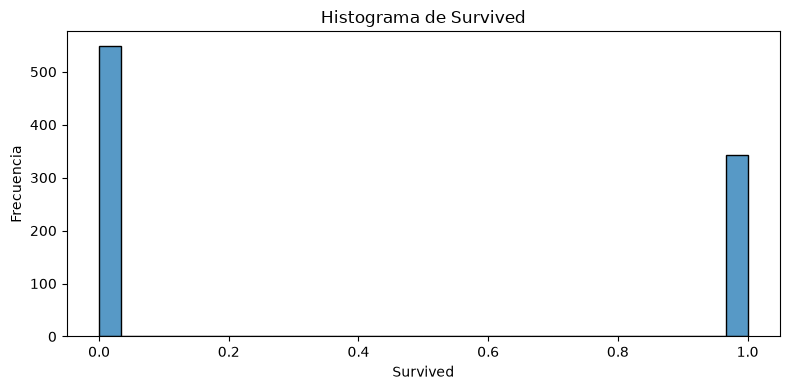

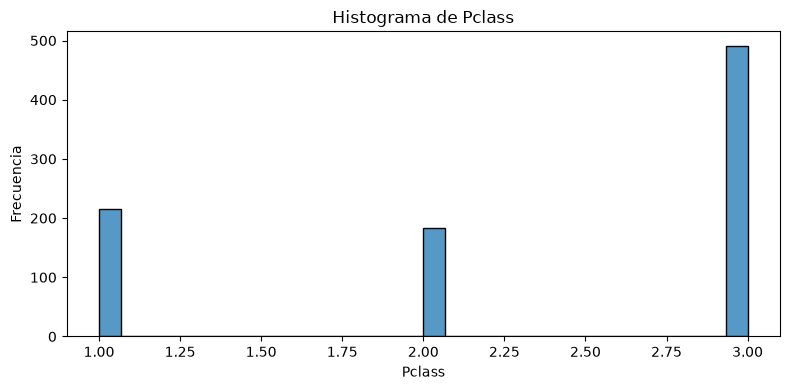

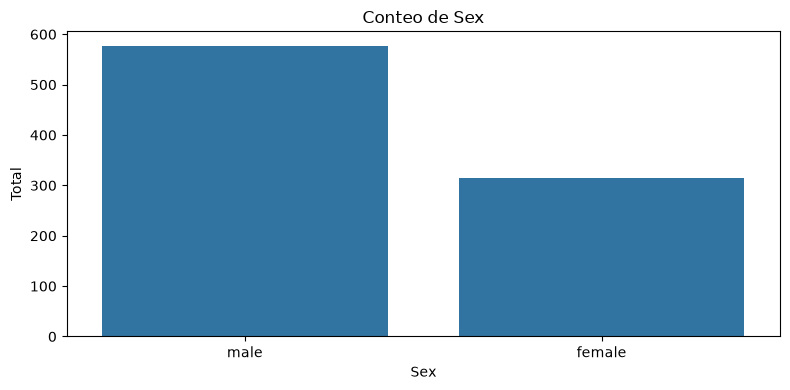

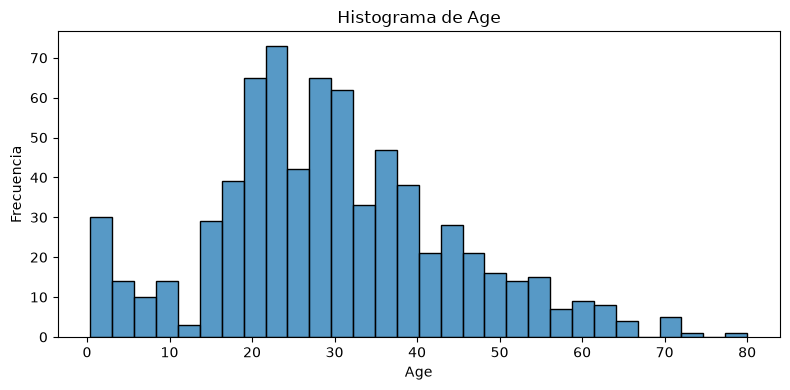

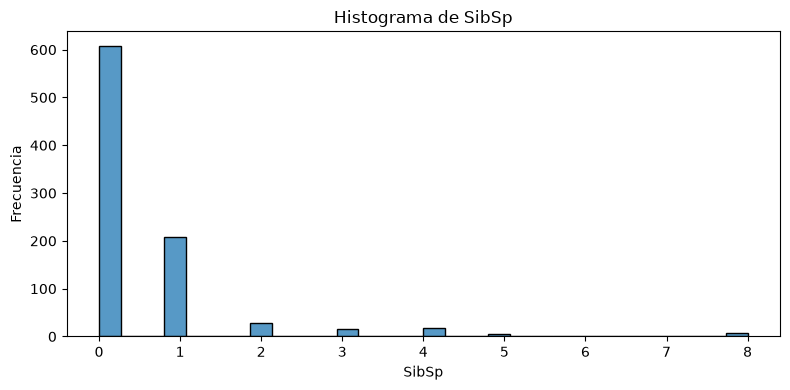

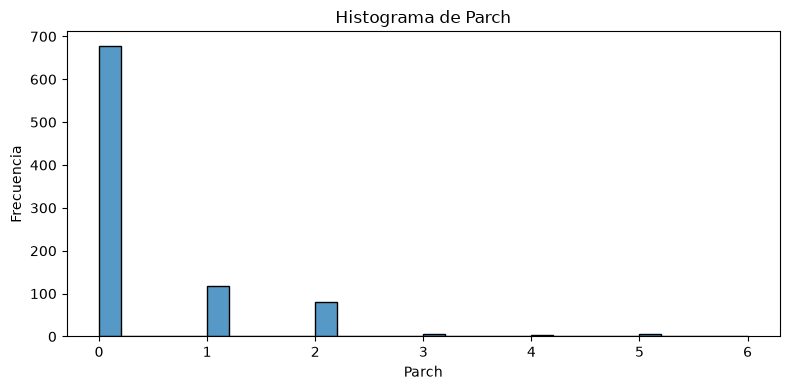

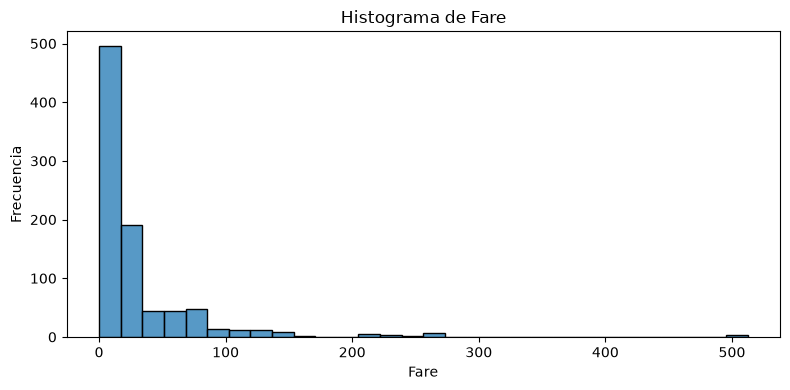

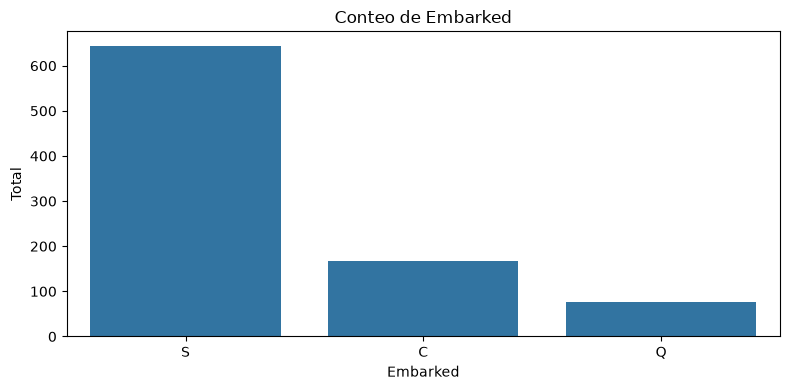

In [16]:
# Pintamos solo las variables con sentido (excluimos identificadores y texto libre)
cols_plot = [c for c in df.columns if c not in ['PassengerId', 'Name', 'Ticket', 'Cabin']]
for column in cols_plot:
    plt.figure(figsize=(8, 4))
    if pd.api.types.is_numeric_dtype(df[column]):
        sns.histplot(df[column].dropna(), bins=30)
        plt.title(f'Histograma de {column}')
        plt.ylabel('Frecuencia')
    else:
        sns.countplot(x=df[column])
        plt.title(f'Conteo de {column}')
        plt.ylabel('Total')
    plt.tight_layout()
    plt.show()

In [ ]:
# Genera boxplots para cada columna numérica del DataFrame
df.boxplot(figsize=(10, 8), rot=45)
plt.title('Boxplots de todas las columnas')
plt.tight_layout()  # Para ajustar mejor el espacio de la gráfica
plt.show()

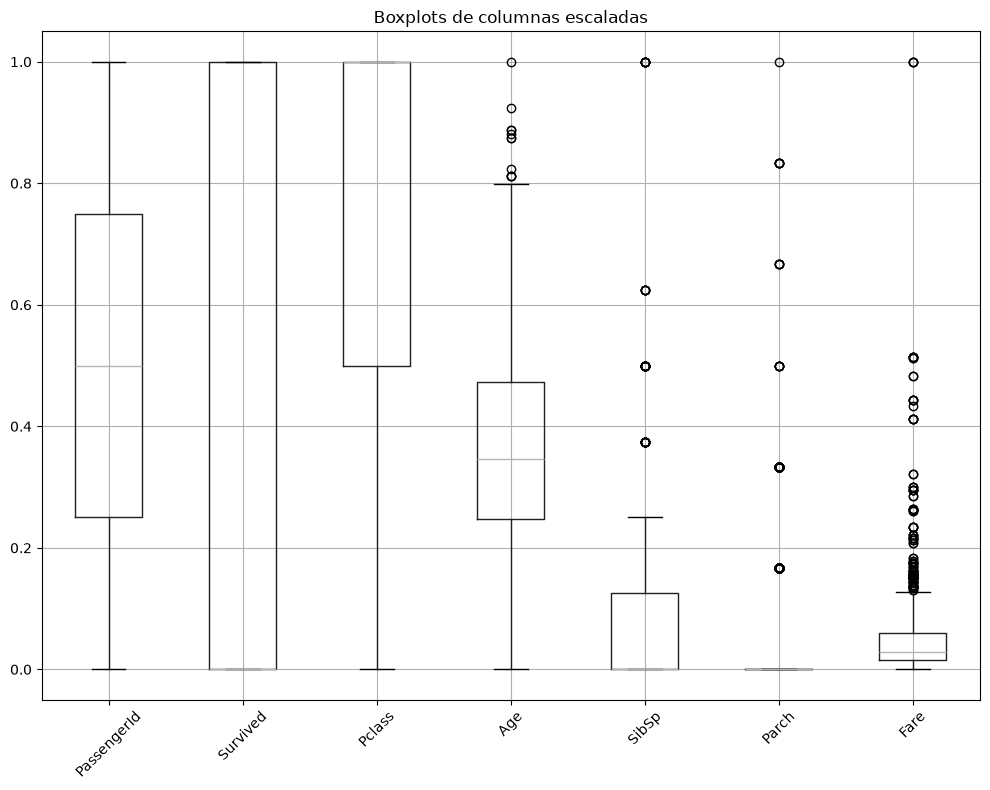

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Seleccionamos solo las columnas numéricas
numeric_columns = df.select_dtypes(include=['float', 'int']).columns
df_numeric = df[numeric_columns]

# Normalizamos los datos entre 0 y 1
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=numeric_columns)

# Genera boxplots para las columnas escaladas
df_scaled.boxplot(figsize=(10, 8), rot=45)
plt.title('Boxplots de columnas escaladas')
plt.tight_layout()
plt.show()

#### Comentarios:
Los valores parecen ser coherentes.

### Análisis Multivariable

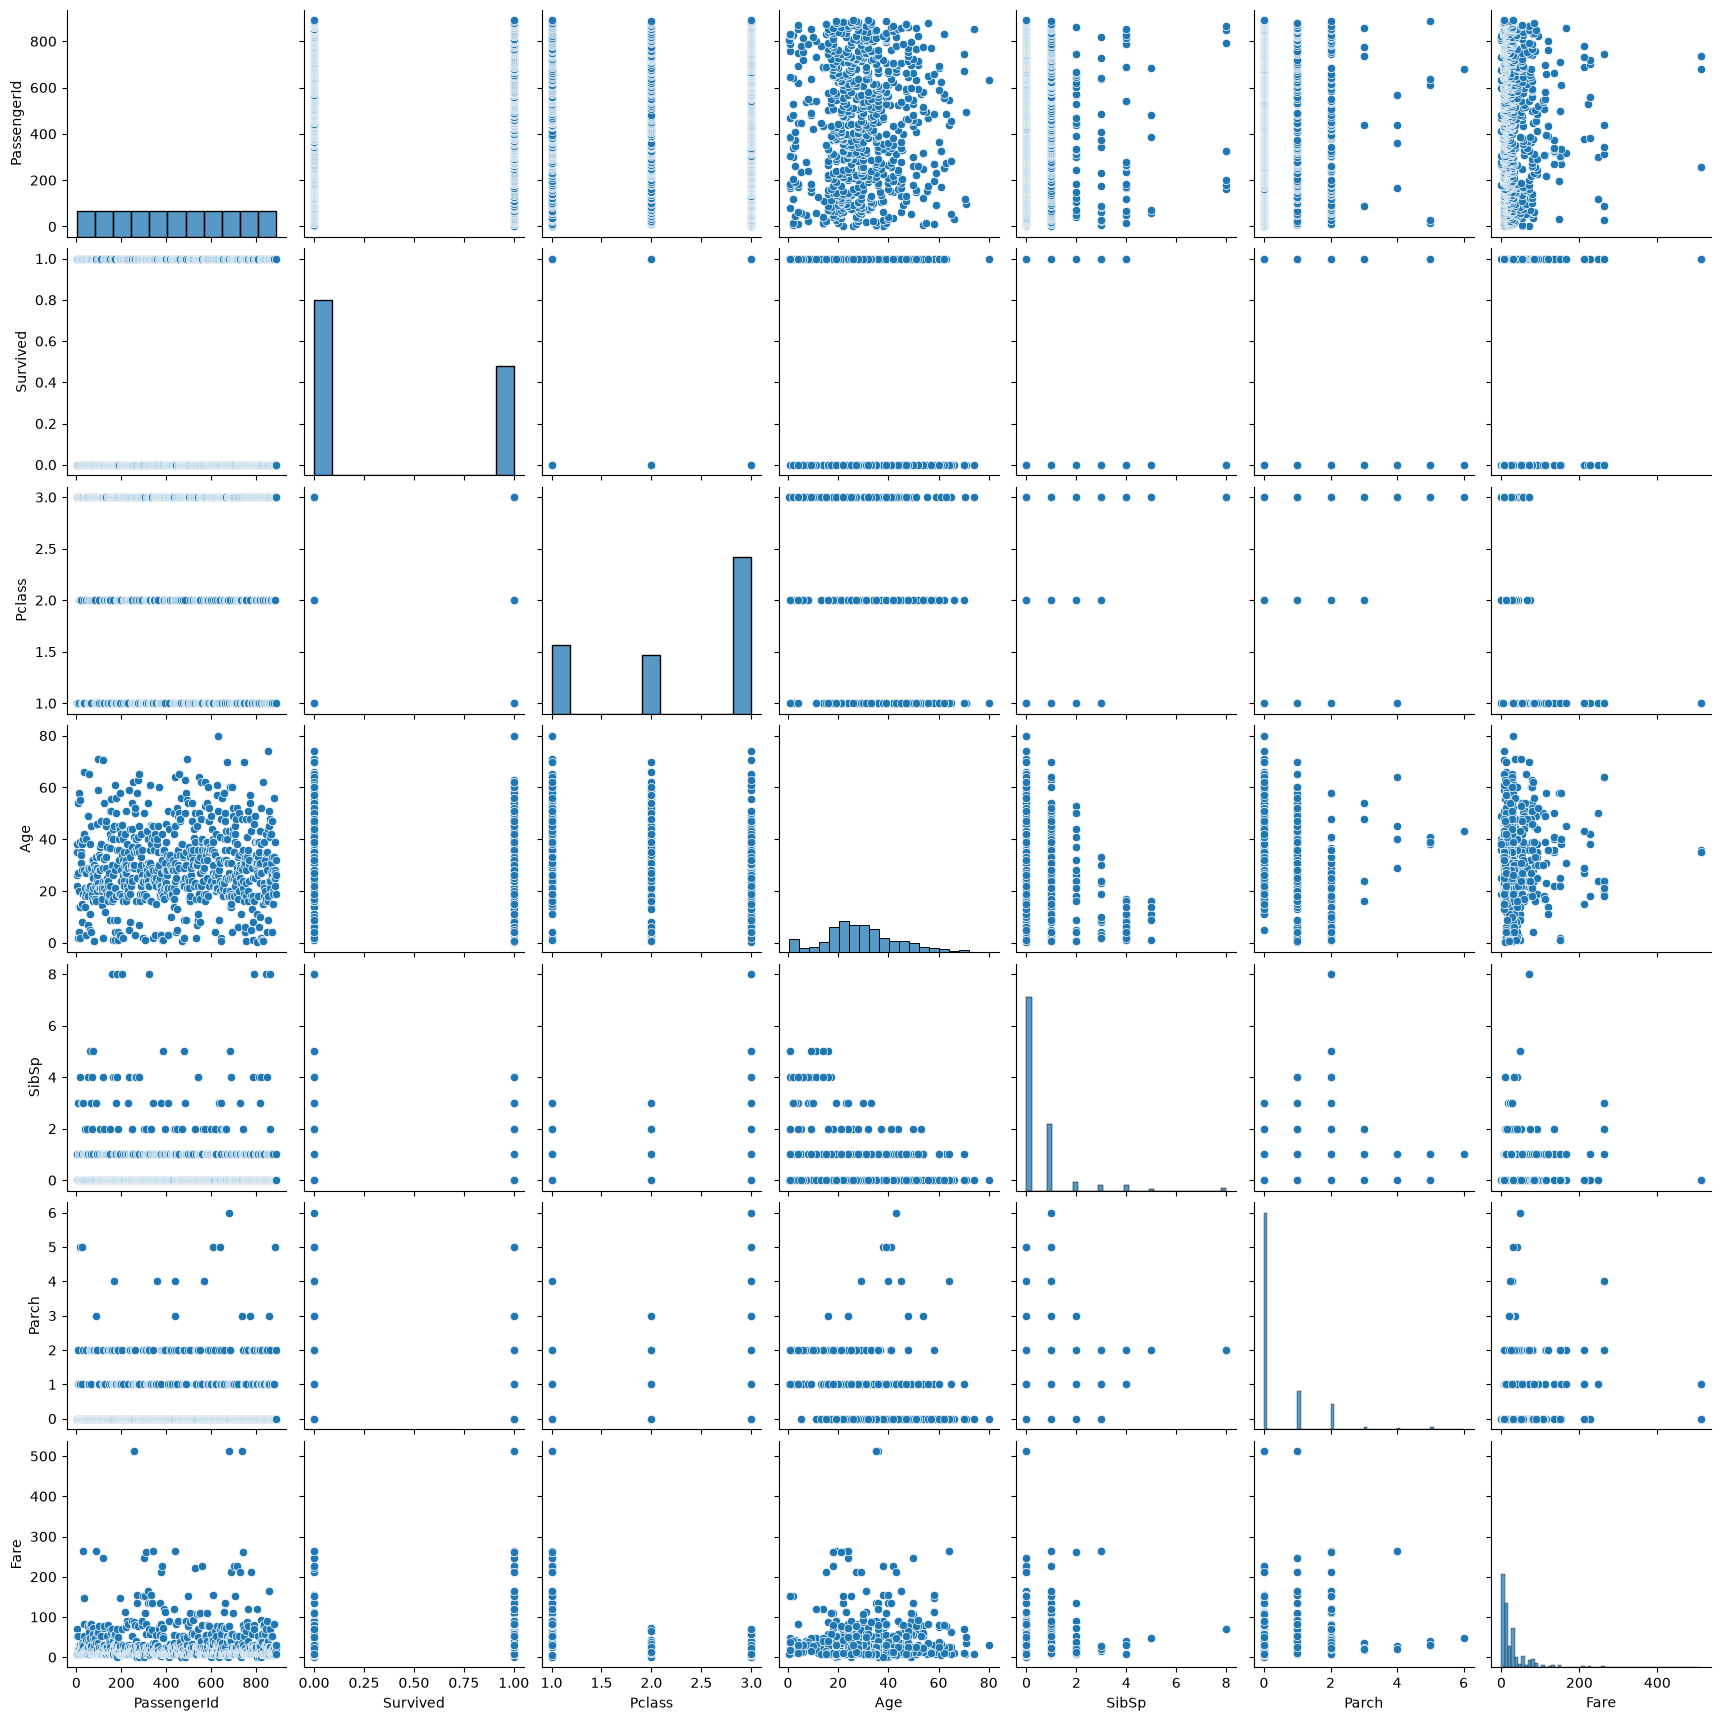

In [18]:
sns.pairplot(df);

In [20]:
# Correlaciones
df[num_columns].corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [21]:
# Defino un cmap para ver más claramente los colores
cmap = sns.diverging_palette(500, 10, as_cmap=True)

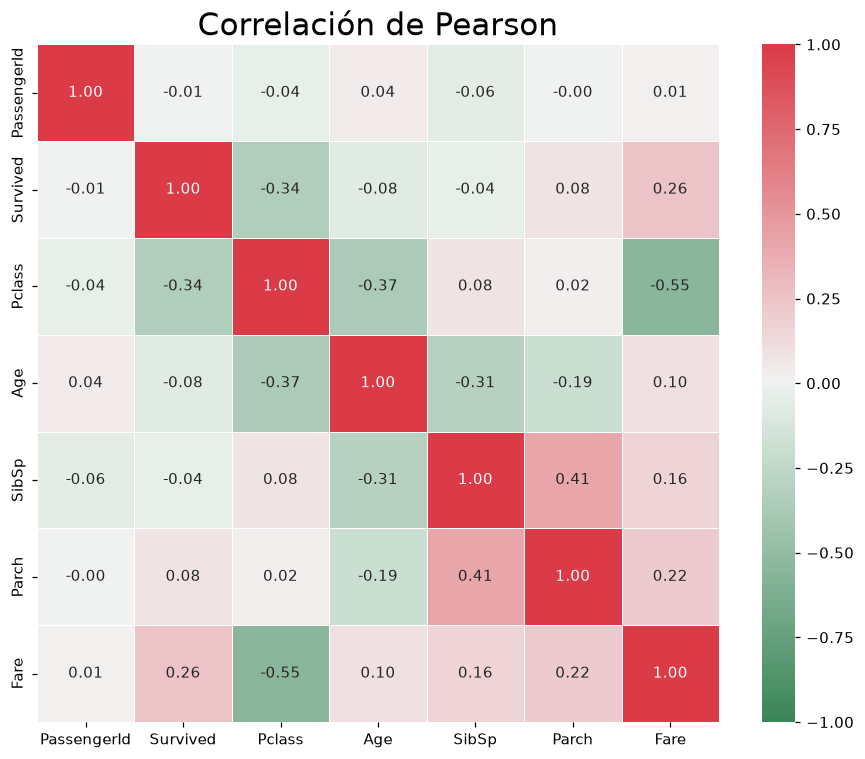

In [22]:
plt.figure(figsize=(10,8), dpi=110)
sns.heatmap(df[num_columns].corr(method='pearson'),
            annot=True, 
            fmt=".2f", linewidth=.5, cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlación de Pearson", fontsize =20)
plt.show()

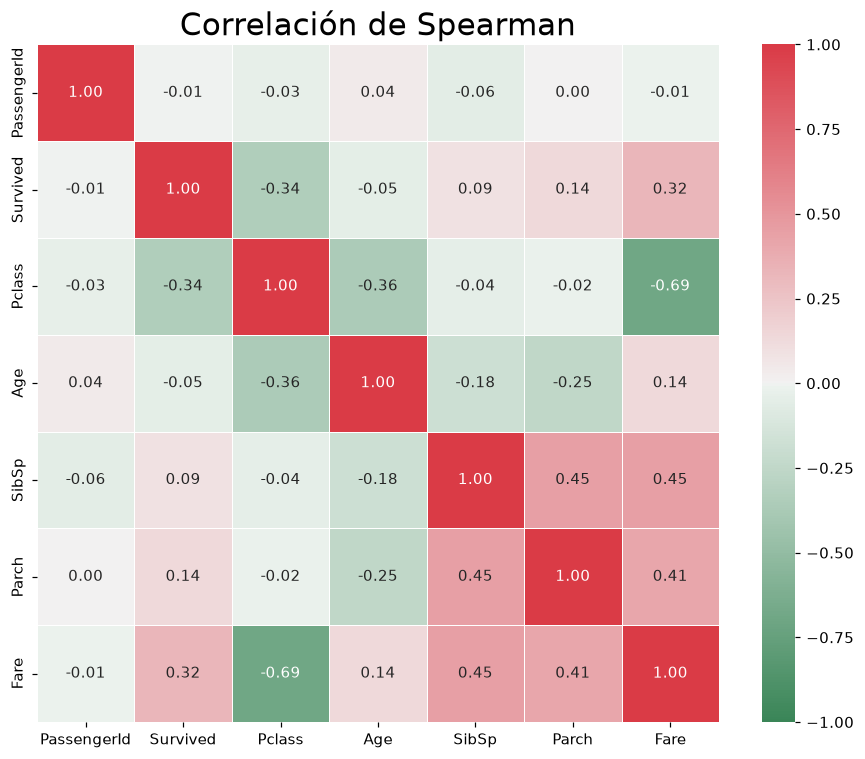

In [23]:
plt.figure(figsize=(10,8), dpi=110)
sns.heatmap(df[num_columns].corr(method='spearman'),
            annot=True, 
            fmt=".2f", linewidth=.5, cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlación de Spearman", fontsize =20)
plt.show()

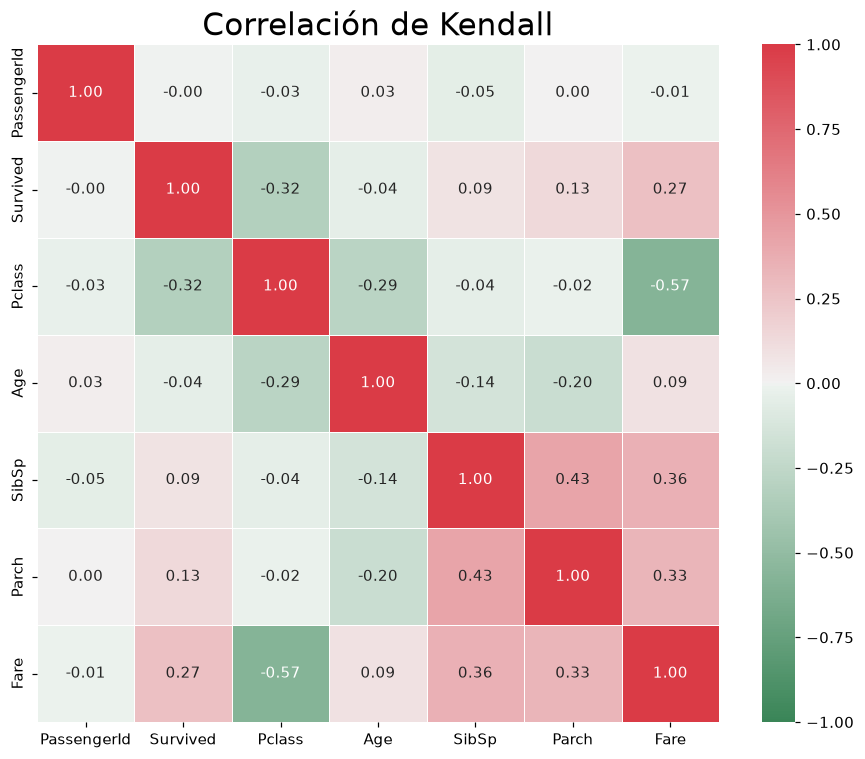

In [24]:
plt.figure(figsize=(10,8), dpi=110)
sns.heatmap(df[num_columns].corr(method='kendall'),
            annot=True, 
            fmt=".2f", linewidth=.5, cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlación de Kendall", fontsize =20)
plt.show()

#### Comentarios:
No parece que haya correlaciones demasiado fuertes entre variables, salvo la trivial (clase-tarifa)

### Testeo Hipótesis

> **Cómo testear cada hipótesis (guía):** para cada una, apóyate en un **gráfico** (p. ej. `pd.crosstab(..., normalize='index').plot(kind='bar', stacked=True)` o un `groupby('...')['Survived'].mean()`) y confírmalo con una **prueba estadística**:
> - Variables **categóricas** (Sex, Pclass, Embarked, Has_Cabin, Title…): **chi²** con `scipy.stats.chi2_contingency` sobre `pd.crosstab(var, Survived)`.
> - Variables **numéricas** (Age, Fare…): **t-test** con `scipy.stats.ttest_ind` comparando supervivientes vs no supervivientes.
>
> Interpreta el p-valor: si **p < 0.05**, la relación/diferencia es estadísticamente significativa.

1. **Hipótesis de Género**: Las mujeres tuvieron una mayor probabilidad de sobrevivir que los hombres debido al protocolo de evacuación de "mujeres y niños primero".

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


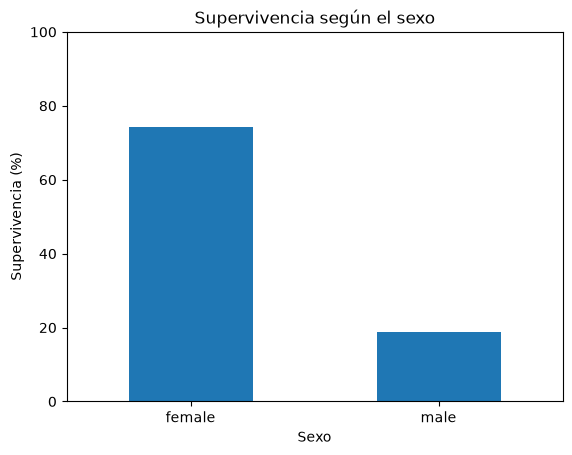

In [ ]:
# Porcentaje de supervivencia según el sexo
supervivencia_sexo = df.groupby('Sex')['Survived'].mean() * 100
print(supervivencia_sexo)

# Gráfico de los porcentajes
supervivencia_sexo.plot(kind='bar')
plt.title('Supervivencia según el sexo')
plt.xlabel('Sexo')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()
#Sobrevivieron mas mujeres que hombres 

In [ ]:
# Tabla de recuentos: sexo y supervivencia
tabla = pd.crosstab(df['Sex'], df['Survived'])
print(tabla)

# Prueba chi-cuadrado
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla)
print("p-valor:", p_valor)


#al ser el p-valor < 0.05, podemos rechazar la hipótesis nula y concluir que hay una relación significativa entre el sexo y la supervivencia en el Titanic.

Survived    0    1
Sex               
female     81  233
male      468  109
p-valor: 1.197357062775565e-58


2. **Hipótesis de Clase**: Los pasajeros de clases más altas (`Pclass = 1`) tuvieron una mayor probabilidad de sobrevivir en comparación con los pasajeros de clases más bajas, reflejando las desigualdades sociales de la época.

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


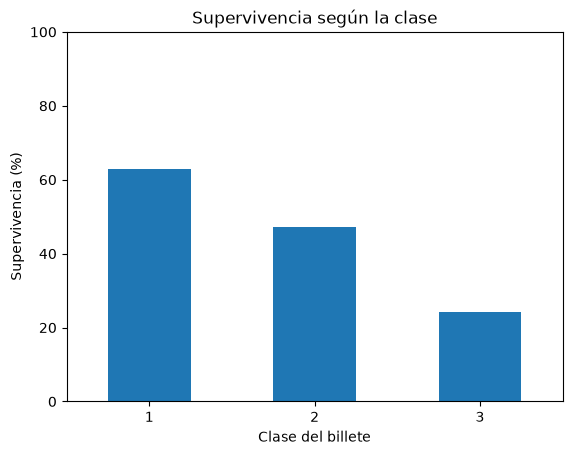

In [ ]:
# @TODO: testear hipótesis

In [ ]:
#hay un 62,96% de supervivencia en la primera clase, un 47% en la segunda clase y un 24% en la tercera clase. Esto indica que los pasajeros de primera clase tenían una mayor probabilidad de sobrevivir en comparación con los de segunda y tercera clase.
# Recuento de pasajeros por clase y supervivencia
tabla_clase = pd.crosstab(df['Pclass'], df['Survived'])
print(tabla_clase)

# Prueba chi-cuadrado de independencia
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_clase)
print("p-valor:", p_valor)
#Rechazamos la hipotesis nula al ser el p-valor menor que 0.05, por lo que podemos concluir que hay una relación significativa entre la clase del billete y la supervivencia en el Titanic.

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119
p-valor: 4.549251711298793e-23


3. **Hipótesis de Edad**: Los pasajeros más jóvenes (niños) tuvieron una mayor probabilidad de sobrevivir debido a que se les dio prioridad en los esfuerzos de rescate.

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


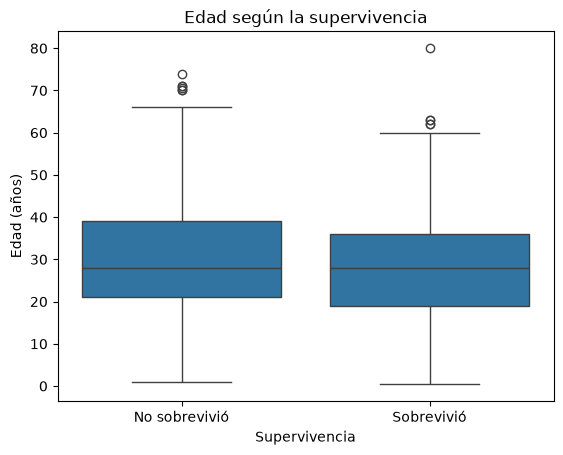

In [33]:
# Edad media según la supervivencia
edad_media = df.groupby('Survived')['Age'].mean()
print(edad_media)

# Distribución de edades según la supervivencia
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Edad según la supervivencia')
plt.xlabel('Supervivencia')
plt.ylabel('Edad (años)')
plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])
plt.show()

In [6]:
# Edades de cada grupo, excluyendo los valores faltantes
edad_supervivientes = df.loc[df['Survived'] == 1, 'Age'].dropna()
edad_no_supervivientes = df.loc[df['Survived'] == 0, 'Age'].dropna()

# T-test de Welch: no presupone que las varianzas sean iguales
t_stat, p_valor = ttest_ind(
    edad_supervivientes,
    edad_no_supervivientes,
    equal_var=False
)

print("p-valor:", p_valor)

#l p-valor = 0,0412 es menor que 0,05, así que rechazamos H₀: hay evidencia estadística de una diferencia en la edad media entre supervivientes y no supervivientes.

p-valor: 0.04118965162586641


4. **Hipótesis de Tamaño de la Familia**: Los pasajeros que viajaban con familia tuvieron mayores probabilidades de sobrevivir en comparación con aquellos que viajaban solos. Sin embargo, familias muy grandes pudieron tener dificultades para escapar juntas, reduciendo sus posibilidades de supervivencia.

            pasajeros  supervivencia
FamilySize                          
1                 537      30.353818
2                 161      55.279503
3                 102      57.843137
4                  29      72.413793
5                  15      20.000000
6                  22      13.636364
7                  12      33.333333
8                   6       0.000000
11                  7       0.000000


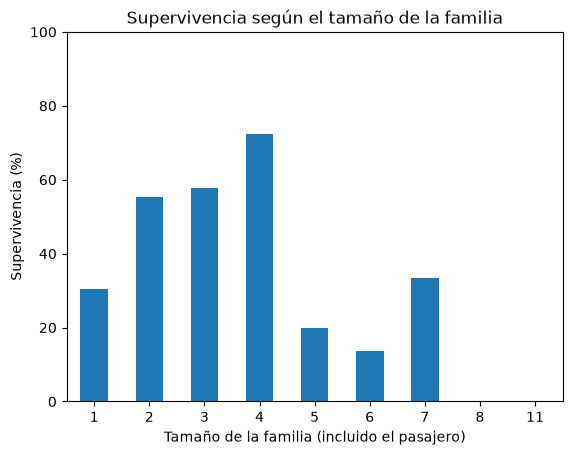

In [7]:
# Tamaño de la familia, incluido el propio pasajero
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Número de pasajeros y porcentaje de supervivencia por tamaño
resumen_familia = df.groupby('FamilySize')['Survived'].agg(
    pasajeros='count',
    supervivencia='mean'
)
resumen_familia['supervivencia'] *= 100
print(resumen_familia)

# Gráfico de los porcentajes
resumen_familia['supervivencia'].plot(kind='bar')
plt.title('Supervivencia según el tamaño de la familia')
plt.xlabel('Tamaño de la familia (incluido el pasajero)')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

In [8]:
# Agrupar el tamaño familiar
df['GrupoFamilia'] = pd.cut(
    df['FamilySize'],
    bins=[0, 1, 4, float('inf')],
    labels=['Solo', 'Familia pequeña', 'Familia grande']
)

# Recuentos y porcentajes de supervivencia
tabla_familia = pd.crosstab(df['GrupoFamilia'], df['Survived'])
print(tabla_familia)

print("\nSupervivencia (%):")
print(tabla_familia[1] / tabla_familia.sum(axis=1) * 100)

# Prueba chi-cuadrado
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_familia)
print("\np-valor:", p_valor)
print("Frecuencia esperada mínima:", esperados.min())

Survived           0    1
GrupoFamilia             
Solo             374  163
Familia pequeña  123  169
Familia grande    52   10

Supervivencia (%):
GrupoFamilia
Solo               30.353818
Familia pequeña    57.876712
Familia grande     16.129032
dtype: float64

p-valor: 6.522919536640471e-17
Frecuencia esperada mínima: 23.7979797979798


               mean  median
Survived                   
0         22.117887    10.5
1         48.395408    26.0


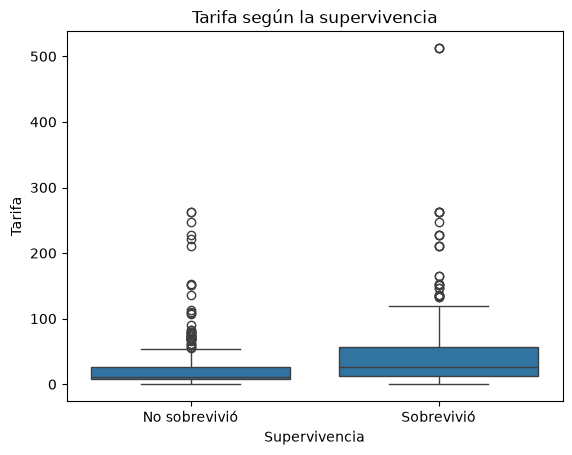

In [9]:
# Media y mediana de la tarifa según la supervivencia
resumen_tarifa = df.groupby('Survived')['Fare'].agg(['mean', 'median'])
print(resumen_tarifa)

# Distribución de las tarifas
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Tarifa según la supervivencia')
plt.xlabel('Supervivencia')
plt.ylabel('Tarifa')
plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])
plt.show()

In [ ]:
# Tarifas de cada grupo, excluyendo valores faltantes
tarifa_supervivientes = df.loc[df['Survived'] == 1, 'Fare'].dropna()
tarifa_no_supervivientes = df.loc[df['Survived'] == 0, 'Fare'].dropna()

# Comparación de medias
t_stat, p_valor = ttest_ind(
    tarifa_supervivientes,
    tarifa_no_supervivientes,
    equal_var=False
)

print("p-valor:", p_valor)

#Ese p-valor es 0,00000000002699, mucho menor que 0,05. Por tanto, rechazamos H₀: la tarifa media difiere significativamente entre supervivientes y no supervivientes.


p-valor: 2.6993323503141203e-11


5. **Hipótesis de la Tarifa**: Los pasajeros que pagaron tarifas más altas tuvieron una mayor probabilidad de sobrevivir, ya que es probable que estuvieran en camarotes de clases superiores y tuvieran mejor acceso a los botes salvavidas.

In [14]:
# Comparar tarifas según la supervivencia
df.groupby('Survived')['Fare'].agg(['mean', 'median'])




,mean,median
Survived,,
0,22.117887,10.5
1,48.395408,26.0


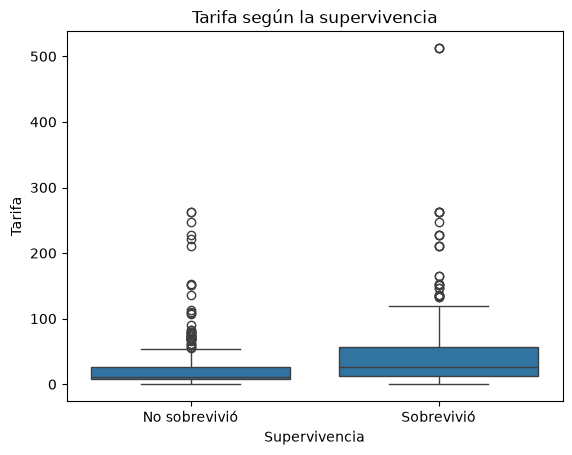

In [13]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Tarifa según la supervivencia')
plt.xlabel('Supervivencia')
plt.ylabel('Tarifa')
plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])
plt.show()


In [ ]:
# Tarifas de cada grupo, excluyendo valores faltantes
tarifa_supervivientes = df.loc[df['Survived'] == 1, 'Fare'].dropna()
tarifa_no_supervivientes = df.loc[df['Survived'] == 0, 'Fare'].dropna()

# Comparación de medias mediante el t-test de Welch
t_stat, p_valor = ttest_ind(
    tarifa_supervivientes,
    tarifa_no_supervivientes,
    equal_var=False
)

print("p-valor:", p_valor)

#El t-test de Welch obtiene un p-valor de 2,70 × 10⁻¹¹, inferior a 0,05. Rechazamos la igualdad de medias. Como los supervivientes pagaron una tarifa media mayor, el resultado apoya la hipótesis 5. Sin embargo, no demuestra que pagar más causara una mayor supervivencia.

p-valor: 2.6993323503141203e-11


6. **Hipótesis del Punto de Embarque**: Los pasajeros que embarcaron en ciertos puntos, como Cherburgo (`Embarked = C`), tuvieron mayores probabilidades de sobrevivir debido a diferencias en riqueza o ubicación de los camarotes.

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


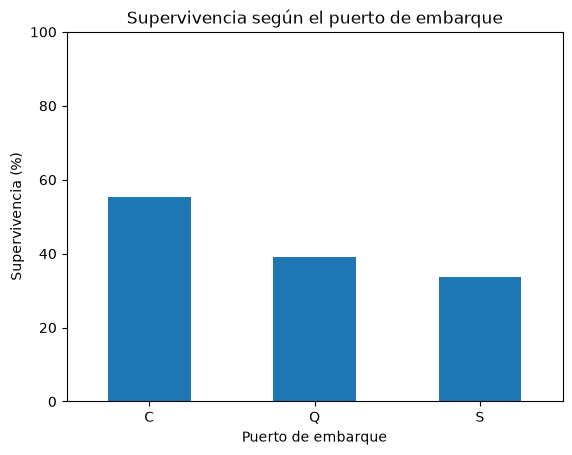

In [16]:
# Porcentaje de supervivencia según el puerto de embarque
supervivencia_puerto = df.groupby('Embarked')['Survived'].mean() * 100
print(supervivencia_puerto)

# Gráfico de los porcentajes
supervivencia_puerto.plot(kind='bar')
plt.title('Supervivencia según el puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()


In [ ]:
# Recuento de pasajeros por puerto y supervivencia
tabla_puerto = pd.crosstab(df['Embarked'], df['Survived'])
print(tabla_puerto)

# Prueba chi-cuadrado de independencia
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_puerto)
print("p-valor:", p_valor)

#La prueba chi-cuadrado indica una asociación significativa entre el puerto de embarque y la supervivencia (p ≈ 0,00000177). Cherburgo presenta el mayor porcentaje de supervivientes (55,36 %), lo que apoya la hipótesis 6. Sin embargo, no demuestra que el puerto causara esa diferencia ni permite atribuirla directamente a la riqueza o ubicación de los camarotes. Se excluyeron los pasajeros sin puerto registrado.

Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217
p-valor: 1.769922284120912e-06


7. **Hipótesis de Disponibilidad de Cabina**: Los pasajeros con información de cabina disponible (`Cabin` no nulo) tuvieron una mayor probabilidad de sobrevivir, ya que probablemente estaban en las secciones de clase alta del barco.

Has_Cabin
0    29.985444
1    66.666667
Name: Survived, dtype: float64


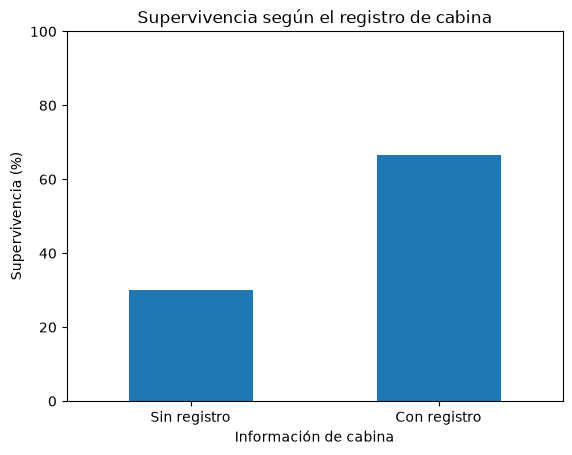

In [18]:
# Identificar si hay información de cabina
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

# Porcentaje de supervivencia según la disponibilidad del dato
supervivencia_cabina = df.groupby('Has_Cabin')['Survived'].mean() * 100
print(supervivencia_cabina)

# Gráfico de los porcentajes
supervivencia_cabina.plot(kind='bar')
plt.title('Supervivencia según el registro de cabina')
plt.xlabel('Información de cabina')
plt.ylabel('Supervivencia (%)')
plt.xticks([0, 1], ['Sin registro', 'Con registro'], rotation=0)
plt.ylim(0, 100)
plt.show()

In [ ]:
# Recuento según el registro de cabina y la supervivencia
tabla_cabina = pd.crosstab(df['Has_Cabin'], df['Survived'])
print(tabla_cabina)

# Prueba chi-cuadrado de independencia
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_cabina)
print("p-valor:", p_valor)

#Los pasajeros con información de cabina registrada presentan mayor supervivencia (66,67 %) que aquellos sin ese dato (29,99 %). La prueba chi-cuadrado indica una asociación estadísticamente significativa (p ≈ 6,74 × 10⁻²¹), lo que apoya la hipótesis 7. Esto no demuestra causalidad ni confirma que la diferencia se deba a la clase del pasajero. La ausencia del dato tampoco significa que no tuviera cabina.

Survived     0    1
Has_Cabin          
0          481  206
1           68  136
p-valor: 6.741970436081179e-21


8. **Hipótesis de Título**: Los pasajeros con ciertos títulos, como `Mrs`, `Miss` o `Master` (niños), tuvieron mejores probabilidades de sobrevivir que otros, reflejando su estatus social o edad.

              pasajeros  supervivencia
Title                                 
Capt                  1       0.000000
Col                   2      50.000000
Don                   1       0.000000
Dr                    7      42.857143
Jonkheer              1       0.000000
Lady                  1     100.000000
Major                 2      50.000000
Master               40      57.500000
Miss                182      69.780220
Mlle                  2     100.000000
Mme                   1     100.000000
Mr                  517      15.667311
Mrs                 125      79.200000
Ms                    1     100.000000
Rev                   6       0.000000
Sir                   1     100.000000
the Countess          1     100.000000


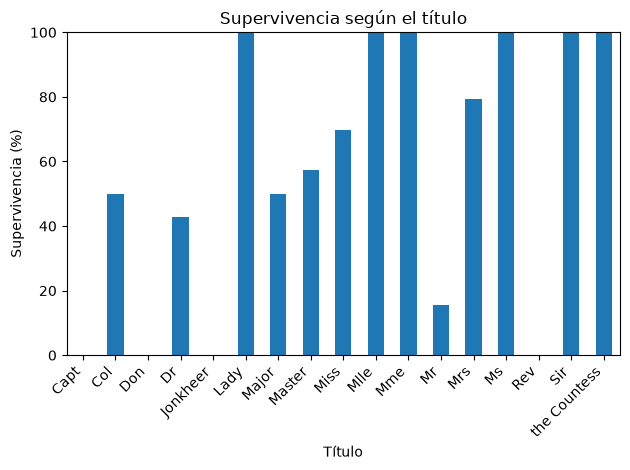

In [20]:
# Extraer el título que aparece entre la coma y el punto
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
df['Title'] = df['Title'].str.strip()

# Número de pasajeros y porcentaje de supervivencia por título
resumen_titulo = df.groupby('Title')['Survived'].agg(
    pasajeros='count',
    supervivencia='mean'
)
resumen_titulo['supervivencia'] *= 100
print(resumen_titulo)

# Gráfico de los porcentajes
resumen_titulo['supervivencia'].plot(kind='bar')
plt.title('Supervivencia según el título')
plt.xlabel('Título')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Unificar títulos equivalentes
df['Title_group'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# Agrupar los títulos menos frecuentes
titulos_principales = ['Mr', 'Mrs', 'Miss', 'Master']

df.loc[
    ~df['Title_group'].isin(titulos_principales),
    'Title_group'
] = 'Rare'

# Recuentos y porcentajes
tabla_titulo = pd.crosstab(df['Title_group'], df['Survived'])
print(tabla_titulo)

print("\nSupervivencia (%):")
print(tabla_titulo[1] / tabla_titulo.sum(axis=1) * 100)

# Prueba chi-cuadrado
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_titulo)
print("\np-valor:", p_valor)
print("Frecuencia esperada mínima:", esperados.min())


#Existe una asociación estadísticamente significativa entre el título y la supervivencia (p ≈ 3,96 × 10⁻⁶¹). Los grupos Mrs, Miss y Master presentan mayores porcentajes de supervivencia que Mr, lo que apoya la hipótesis 8. La prueba es global y no demuestra por separado cada diferencia entre títulos. Tampoco demuestra causalidad, ya que los títulos reflejan otras características, como el sexo y la edad.

Survived       0    1
Title_group          
Master        17   23
Miss          55  130
Mr           436   81
Mrs           26  100
Rare          15    8

Supervivencia (%):
Title_group
Master    57.500000
Miss      70.270270
Mr        15.667311
Mrs       79.365079
Rare      34.782609
dtype: float64

p-valor: 3.957861347159744e-61
Frecuencia esperada mínima: 8.828282828282829


9. **Hipótesis del Número de Ticket**: Los pasajeros con números de ticket similares, lo que podría indicar que viajaban juntos, tuvieron probabilidades de supervivencia correlacionadas.

In [22]:
# Agrupar pasajeros con el mismo billete
resumen_ticket = df.groupby('Ticket')['Survived'].agg(
    pasajeros='count',
    supervivientes='sum',
    supervivencia='mean'
)

# Seleccionar los billetes compartidos por varios pasajeros
tickets_compartidos = resumen_ticket[
    resumen_ticket['pasajeros'] > 1
].copy()

tickets_compartidos['supervivencia'] *= 100

# Mostrar los 10 grupos más numerosos
print(
    tickets_compartidos
    .sort_values('pasajeros', ascending=False)
    .head(10)
)

              pasajeros  supervivientes  supervivencia
Ticket                                                
CA. 2343              7               0       0.000000
347082                7               0       0.000000
1601                  7               5      71.428571
347088                6               0       0.000000
CA 2144               6               0       0.000000
3101295               6               0       0.000000
S.O.C. 14879          5               0       0.000000
382652                5               0       0.000000
349909                4               0       0.000000
LINE                  4               1      25.000000


Resultado
Resultado mixto        49
Todos sobrevivieron    48
Ninguno sobrevivió     37
Name: count, dtype: int64


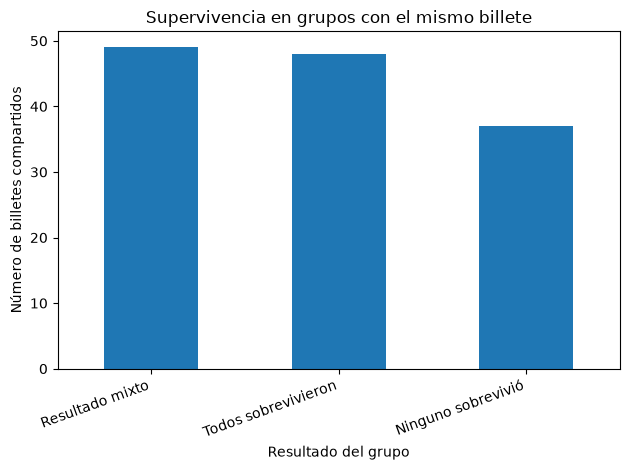

In [23]:
# Clasificar el resultado de cada billete compartido
def clasificar_resultado(porcentaje):
    if porcentaje == 0:
        return 'Ninguno sobrevivió'
    elif porcentaje == 100:
        return 'Todos sobrevivieron'
    else:
        return 'Resultado mixto'

tickets_compartidos['Resultado'] = (
    tickets_compartidos['supervivencia'].apply(clasificar_resultado)
)

# Contar los billetes de cada categoría
recuento = tickets_compartidos['Resultado'].value_counts()
print(recuento)

# Representar los resultados
recuento.plot(kind='bar')
plt.title('Supervivencia en grupos con el mismo billete')
plt.xlabel('Resultado del grupo')
plt.ylabel('Número de billetes compartidos')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#En el 63,43 % de los grupos con un mismo billete, todos los pasajeros tuvieron el mismo desenlace. Este resultado es compatible con la hipótesis 9, pero no permite confirmarla: todavía no hemos comprobado si esa coincidencia supera lo esperable por azar.
#En total, 85 de 134 grupos (63,43 %) tuvieron el mismo desenlace para todos sus integrantes.

10. **Hipótesis de Interacciones**:
    - **Género y Clase**: Las mujeres de clases más altas tuvieron la mayor tasa de supervivencia.
    - **Edad y Clase**: Los niños de clases más bajas tuvieron menos probabilidades de sobrevivir que los niños de clases más altas.
    - **Tamaño de Familia y Tarifa**: Los pasajeros con familias más pequeñas y tarifas más altas tuvieron mayores probabilidades de supervivencia.

Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


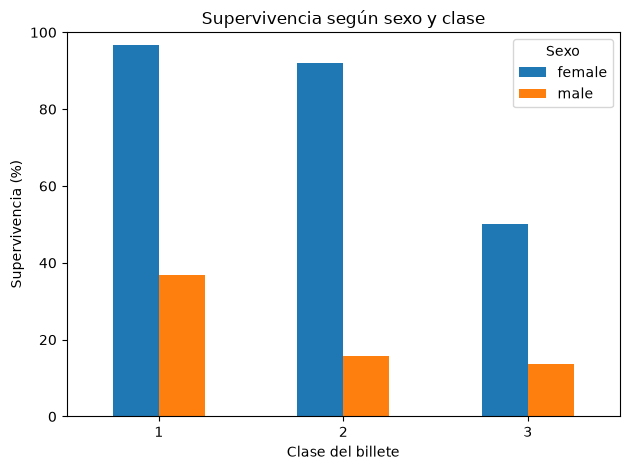

In [24]:
# Porcentaje de supervivencia por sexo y clase
supervivencia_sexo_clase = (
    df.groupby(['Pclass', 'Sex'])['Survived']
    .mean()
    .unstack() * 100
)

print(supervivencia_sexo_clase)

# Gráfico comparativo
supervivencia_sexo_clase.plot(kind='bar')
plt.title('Supervivencia según sexo y clase')
plt.xlabel('Clase del billete')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

        pasajeros  supervivencia
Pclass                          
1              12      91.666667
2              23      91.304348
3              78      37.179487


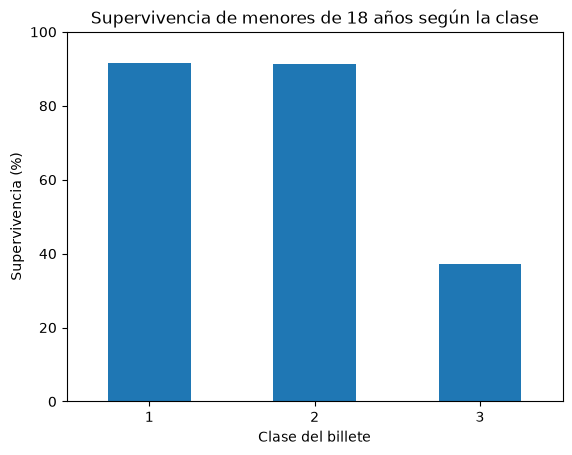

In [25]:
# Seleccionar menores de 18 años con edad conocida
menores = df.loc[df['Age'].notna() & (df['Age'] < 18)]

# Número de menores y porcentaje de supervivencia por clase
resumen_menores = menores.groupby('Pclass')['Survived'].agg(
    pasajeros='count',
    supervivencia='mean'
)

resumen_menores['supervivencia'] *= 100
print(resumen_menores)

# Gráfico de los porcentajes
resumen_menores['supervivencia'].plot(kind='bar')
plt.title('Supervivencia de menores de 18 años según la clase')
plt.xlabel('Clase del billete')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

                                          pasajeros  supervivencia
GrupoFamilia    GrupoTarifa                                       
Solo            Hasta la mediana                397      23.677582
                Por encima de la mediana        140      49.285714
Familia pequeña Hasta la mediana                 49      34.693878
                Por encima de la mediana        243      62.551440
Familia grande  Hasta la mediana                  1     100.000000
                Por encima de la mediana         61      14.754098


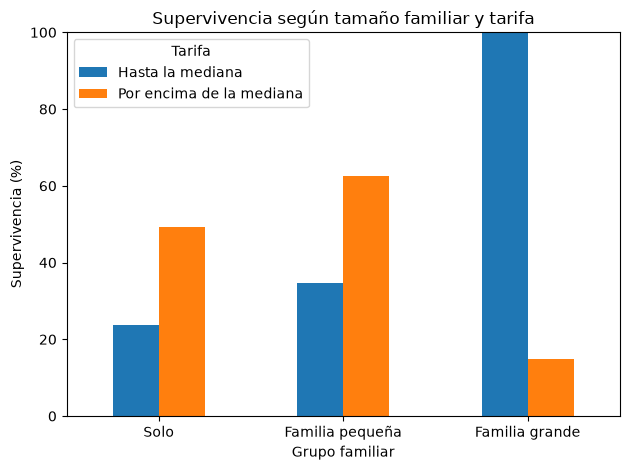

In [27]:
# Dividir las tarifas usando la mediana
mediana_tarifa = df['Fare'].median()

df['GrupoTarifa'] = pd.cut(
    df['Fare'],
    bins=[-float('inf'), mediana_tarifa, float('inf')],
    labels=['Hasta la mediana', 'Por encima de la mediana']
)

# Recuentos y porcentajes por grupo familiar y tarifa
resumen = df.groupby(
    ['GrupoFamilia', 'GrupoTarifa'],
    observed=True
)['Survived'].agg(
    pasajeros='count',
    supervivencia='mean'
)

resumen['supervivencia'] *= 100
print(resumen)

# Gráfico de los porcentajes
resumen['supervivencia'].unstack().plot(kind='bar')
plt.title('Supervivencia según tamaño familiar y tarifa')
plt.xlabel('Grupo familiar')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title='Tarifa')
plt.tight_layout()
plt.show()

In [28]:
print("SEXO Y CLASE — Supervivencia (%)")
print(supervivencia_sexo_clase)

print("\nMENORES DE 18 AÑOS POR CLASE")
print(resumen_menores)

print("\nTAMAÑO FAMILIAR Y TARIFA")
print(resumen)

SEXO Y CLASE — Supervivencia (%)
Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669

MENORES DE 18 AÑOS POR CLASE
        pasajeros  supervivencia
Pclass                          
1              12      91.666667
2              23      91.304348
3              78      37.179487

TAMAÑO FAMILIAR Y TARIFA
                                          pasajeros  supervivencia
GrupoFamilia    GrupoTarifa                                       
Solo            Hasta la mediana                397      23.677582
                Por encima de la mediana        140      49.285714
Familia pequeña Hasta la mediana                 49      34.693878
                Por encima de la mediana        243      62.551440
Familia grande  Hasta la mediana                  1     100.000000
                Por encima de la mediana         61      14.754098


In [ ]:
# Hipótesis 10: las mujeres de primera clase tuvieron la mayor supervivencia (96,81 %).
# Los menores de tercera clase sobrevivieron menos (37,18 %) que los de primera y segunda (≈91 %).
# Las familias pequeñas con tarifa alta sobrevivieron más (62,55 %) que las de tarifa baja (34,69 %).
# El 100 % en familias grandes con tarifa baja corresponde a un único pasajero.
# Los resultados apoyan descriptivamente la hipótesis, sin demostrar causalidad ni interacción estadística.

## Conclusiones

# Conclusiones finales del EDA del Titanic

Después de explorar los datos y contrastar las hipótesis, he observado que la supervivencia estuvo relacionada con varias características de los pasajeros. Estas son las principales conclusiones:

1. **Sexo.** Las mujeres tuvieron una supervivencia mucho mayor que los hombres: un 74,20 % frente a un 18,89 %. La prueba chi-cuadrado indica que existe una asociación significativa. Los datos apoyan la hipótesis, aunque no permiten demostrar que la diferencia se debiera al protocolo de «mujeres y niños primero».

2. **Clase del billete.** Sobrevivió el 62,96 % de los pasajeros de primera clase, el 47,28 % de segunda y el 24,24 % de tercera. La asociación es significativa y muestra una clara diferencia de supervivencia entre clases.

3. **Edad.** Los supervivientes tenían una edad media algo menor: 28,34 años frente a 30,63. El t-test dio un p-valor de 0,0412, inferior a 0,05. Esto apoya que los supervivientes eran más jóvenes en promedio, pero esta comparación no demuestra por sí sola que los niños tuvieran mayor supervivencia. Solo se utilizaron las edades conocidas.

4. **Tamaño familiar.** Viajar con una familia pequeña, de 2 a 4 personas incluyendo al pasajero, estuvo asociado con una mayor supervivencia: 57,88 %, frente al 30,35 % de quienes no tenían familiares registrados y al 16,13 % de las familias grandes. La prueba estadística apoya la asociación. Por tanto, viajar con más familiares no siempre supuso una ventaja.

5. **Tarifa.** Los supervivientes pagaron una tarifa media de 48,40, frente a 22,12 de los no supervivientes. La diferencia es estadísticamente significativa. Esto apoya la hipótesis, pero no significa que pagar más causara una mayor supervivencia, ya que la tarifa también está relacionada con la clase.

6. **Puerto de embarque.** Cherburgo presentó la mayor supervivencia (55,36 %), seguido de Queenstown (38,96 %) y Southampton (33,70 %). Existe una asociación significativa, aunque no podemos atribuir la diferencia al puerto en sí ni explicar su causa con esta comparación.

7. **Información de cabina.** Los pasajeros con cabina registrada tuvieron una supervivencia del 66,67 %, frente al 29,99 % de aquellos sin ese dato. La asociación es significativa. Es importante distinguir entre no tener información de cabina y no disponer de una cabina: los datos solo nos permiten saber lo primero.

8. **Título del pasajero.** Los títulos Mrs, Miss y Master presentaron mayor supervivencia que Mr. La prueba chi-cuadrado indica una asociación global significativa. Los títulos aportan información útil, pero también reflejan características como el sexo y la edad, por lo que no deben interpretarse de forma aislada.

9. **Billetes compartidos.** En 85 de los 134 grupos con el mismo billete, todos los pasajeros tuvieron el mismo desenlace, lo que representa un 63,43 %. Es un patrón compatible con la hipótesis, pero no la considero confirmada: falta comprobar si esa coincidencia supera lo esperable por azar.

10. **Combinación de características.** Las mujeres de primera clase tuvieron la mayor supervivencia (96,81 %). Entre los menores de 18 años, la supervivencia fue mucho menor en tercera clase (37,18 %) que en primera y segunda, ambas alrededor del 91 %. Además, las familias pequeñas con tarifas altas sobrevivieron más que las de tarifas bajas (62,55 % frente a 34,69 %). Estos resultados apoyan descriptivamente las predicciones, pero no se realizó una prueba formal de interacción. El 100 % observado en familias grandes con tarifa baja corresponde a un único pasajero, por lo que no permite generalizar.

Una de las cosas que me llevo del análisis es que no basta con mirar una barra más alta o un p-valor pequeño. También hay que revisar cuántos pasajeros hay en cada grupo, qué datos faltan y cómo se relacionan las variables entre sí. Las pruebas se interpretaron individualmente con un nivel de 0,05, sin ajustar por realizar múltiples contrastes, así que sus resultados deben entenderse dentro de este análisis exploratorio.